In [2]:
import pandas as pd
import numpy as np
import random
import gc
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from datetime import datetime,timedelta

In [3]:
biodata = pd.read_parquet('./datasrc/data/newdata/20251101.parquet')

In [4]:
# biodata.columns

In [5]:
selected_df = biodata[['Subs_Id','Cert_Id_Type','Activation_Date','Birthday_Day']]

list_cert_id = list(selected_df[selected_df['Cert_Id_Type']=='MyKad']['Subs_Id'])

set_subs_id_cert_filtered = set(list_cert_id)
print(len(set_subs_id_cert_filtered))


103899


In [6]:
selected_df = selected_df[selected_df['Subs_Id'].isin(set_subs_id_cert_filtered)]

In [7]:
# selected_df

In [8]:
# ''' 'Birthday_Day' 'Activation_Date' '''

In [9]:
filenames = range(20251101,20251127)

In [10]:
feature_cols = pd.read_parquet(f"./datasrc/data/features/20251101.parquet").columns.tolist()
label_cols = pd.read_parquet(f"./datasrc/data/labels/prepaid_to_postpaid_20251101.parquet").columns.tolist()

all_cols = feature_cols + [label_cols[2]]

In [11]:
all_data_chunks = []
combined_df = pd.DataFrame(columns = all_cols)

In [12]:
for filename in filenames:
    feature_df = pd.read_parquet(f"./datasrc/data/features/{filename}.parquet")
    label_df = pd.read_parquet(f"./datasrc/data/labels/prepaid_to_postpaid_{filename}.parquet")
    context_date = datetime.strptime(str(filename), "%Y%m%d")
    
    left_cols = feature_df.columns[:2].tolist()#joining on sub_id,ctx_date
    right_cols = label_df.columns[:2].tolist()

    joined_df = pd.merge(feature_df, label_df, left_on=left_cols, right_on=right_cols)
    
    joined_df = joined_df[joined_df['Subs_Id'].isin(set_subs_id_cert_filtered)]
        
    all_data_chunks.append(joined_df)
    del feature_df
    del label_df
    gc.collect()


    
combined_df = pd.concat(all_data_chunks, axis=0,ignore_index=True)
del all_data_chunks
gc.collect()

0

In [13]:
# combined_df.columns

In [14]:
print(len(combined_df))

2701374


In [15]:

#age and ageinnetwork as of 26 Nov
# 18*365 <age < 60*365
#ain > 6 months
nov26 = datetime(2025,11,26)

birth_dt = pd.to_datetime(selected_df['Birthday_Day'], format="%Y-%m-%d", errors='coerce')
actvtn_dt = pd.to_datetime(selected_df['Activation_Date'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
selected_df['age'] = (nov26 - birth_dt).dt.days /365.25
selected_df['ain'] = (nov26 - actvtn_dt).dt.days /30.44


In [16]:
selected_df

,Subs_Id,Cert_Id_Type,Activation_Date,Birthday_Day,age,ain
0,102782940340,MyKad,2024-08-13 01:47:04,1990-08-03,35.315537,15.407359
1,103623137760,MyKad,2025-09-06 23:09:16,1976-04-01,49.653662,2.628121
2,103420252627,MyKad,2025-06-01 19:28:36,1973-08-08,52.301164,5.814717
3,103735776391,MyKad,2025-10-24 19:32:22,1977-05-22,48.514716,1.051248
4,103683142435,MyKad,2025-10-01 14:22:26,1962-03-08,63.720739,1.806833
...,...,...,...,...,...,...
199984,103749957690,MyKad,2025-11-01 20:02:44,1995-08-02,30.318960,0.788436
199988,103750028986,MyKad,2025-11-01 20:44:01,1972-10-21,53.097878,0.788436
199990,103750063393,MyKad,2025-11-01 21:01:15,1979-09-26,46.168378,0.788436
199991,103750075610,MyKad,2025-11-01 21:10:13,1999-07-08,26.387406,0.788436


In [17]:
all_subs_id = list(selected_df['Subs_Id'])
all_subs_age = list(selected_df['age'])
all_subs_ain = list(selected_df['ain'])

print(len(all_subs_id))
print(len(all_subs_age))
print(len(all_subs_ain))

103899
103899
103899


In [18]:
biodata_dict = {}
for i in range(0,len(all_subs_id)):
    biodata_dict[all_subs_id[i]] = [0]*2
    biodata_dict[all_subs_id[i]][0] = all_subs_age[i]
    biodata_dict[all_subs_id[i]][1] = all_subs_ain[i]
    


In [19]:

oneday_year = 1/365.25
oneday_months = 1/30.44
nov26 = datetime(2025,11,26).date()

first_ctx_date = datetime(2025,11,1).date()
second_ctx_date = datetime(2025,11,26).date()
age_ain_arr = [] 
ctx_date_inc = first_ctx_date
while(ctx_date_inc <= second_ctx_date):
    for id in all_subs_id:
        details = [0]*4
        details[0] = id
        details[1] = ctx_date_inc
        details[2] = biodata_dict[id][0] - (((nov26 - ctx_date_inc).days)*oneday_year)
        details[3] = biodata_dict[id][1] - (((nov26 - ctx_date_inc).days)*oneday_months)
        if((18 < details[2] < 60) and ( 6 <= details[3])):
            age_ain_arr.append(details)
    ctx_date_inc += timedelta(1)

print(len(age_ain_arr))

            
            
        
        
        
        



1764856


In [20]:
columns_age_ain = ['Subs_Id','ContextDate','age','ain']


In [21]:
age_ain_df = pd.DataFrame(age_ain_arr, columns=columns_age_ain)

In [22]:
age_ain_df.head()

,Subs_Id,ContextDate,age,ain
0,102782940340,2025-11-01,35.247091,14.586071
1,102934253501,2025-11-01,41.900068,12.253614
2,102620606578,2025-11-01,55.367556,17.049934
3,15113186,2025-11-01,50.663929,148.127464
4,102526271934,2025-11-01,49.026694,18.561104


In [23]:
age_ain_df['age'].sum()

np.float64(64177731.07460645)

In [24]:
len(age_ain_df)

1764856

In [25]:
final_df = pd.merge(combined_df, age_ain_df, on=['Subs_Id', 'ContextDate'], how='inner')

In [26]:
len(final_df)

1764856

In [27]:
final_df.head()

,Subs_Id,ContextDate,TotalVoiceChargedDuration60,TotalVoiceFreeDuration60,TotalDataChargeUsage60,TotalDataFreeUsage60,TotalNetwork4gUsage60,TotalNetwork5gUsage60,TotalSmsFreeCount60,TotalVoiceChargeAmount60,...,LastPromotionPurchaseDate,DaysSinceLastAddOnPurchase,DaysSinceLastMacroAddOnPurchase,DaysSinceLastMicroAddOnPurchase,DaysSinceLastPromotionPurchase,DaysUntilMacroAddonExpiry,DaysUntilMicroAddonExpiry,IsMigrated,age,ain
0,102659421383,2025-11-01,0.0,0.0,17880.0,0.0,169.6177,22.4228,0.0,0.0,...,NaT,21,21,21,9999,-8,14,0,50.737851,16.458607
1,102389909489,2025-11-01,0.0,0.0,0.0,0.0,0.1273,0.0000,0.0,0.0,...,NaT,3,3,9999,9999,-176,-9999,0,37.119781,20.729304
2,103285433368,2025-11-01,0.0,0.0,4306.0,139.0,178.3394,144.4886,0.0,0.0,...,NaT,26,26,9999,9999,-3,-9999,0,29.338809,6.997372
3,34769438,2025-11-01,0.0,0.0,14500.0,0.0,313.5459,192.4085,0.0,0.0,...,NaT,1,1,33,9999,-28,26,0,33.007529,120.992116
4,69380667,2025-11-01,0.0,0.0,4953.0,2251.0,80.9938,139.7001,0.0,0.0,...,NaT,25,25,9999,9999,-4,-9999,0,40.791239,68.429698


In [28]:
final_df.columns

Index(['Subs_Id', 'ContextDate', 'TotalVoiceChargedDuration60',
       'TotalVoiceFreeDuration60', 'TotalDataChargeUsage60',
       'TotalDataFreeUsage60', 'TotalNetwork4gUsage60',
       'TotalNetwork5gUsage60', 'TotalSmsFreeCount60',
       'TotalVoiceChargeAmount60',
       ...
       'LastPromotionPurchaseDate', 'DaysSinceLastAddOnPurchase',
       'DaysSinceLastMacroAddOnPurchase', 'DaysSinceLastMicroAddOnPurchase',
       'DaysSinceLastPromotionPurchase', 'DaysUntilMacroAddonExpiry',
       'DaysUntilMicroAddonExpiry', 'IsMigrated', 'age', 'ain'],
      dtype='object', length=112)

In [29]:
# final_df.to_csv('migration_data_filtered_ak.csv', index=False)

In [30]:

all_sub_ids = set(list(final_df['Subs_Id']))
print(len(all_sub_ids))



68734


In [31]:
subid_list = list(all_sub_ids)
random.shuffle(subid_list)
split_idx = int(len(subid_list) * 0.8)
set_80 = set(subid_list[:split_idx])
set_20 = set(subid_list[split_idx:])
print(len(set_80))
print(len(set_20))

54987
13747


In [32]:
model_train = final_df[final_df["Subs_Id"].isin(set_80)]

model_test = final_df[final_df["Subs_Id"].isin(set_20)]



print(f" rows in original DF: {len(final_df)}")
del final_df
gc.collect()
print(f"rows in train DF: {len(model_train)}")
print(f"rows in test DF: {len(model_test)}")

 rows in original DF: 1764856
rows in train DF: 1411603
rows in test DF: 353253


In [33]:
label_train = model_train['IsMigrated']
label_test = model_test['IsMigrated']

In [34]:
label_train.value_counts()

IsMigrated
0    1404454
1       7149
Name: count, dtype: int64

In [35]:
label_test.value_counts()

IsMigrated
0    351750
1      1503
Name: count, dtype: int64

In [36]:
model_train = model_train.drop(columns = ['Subs_Id','Cust_Id','ContextDate','IsMigrated','LastAddOnPackage', 'LastMacroAddOnPackage', 'LastMicroAddOnPackage'])
model_test =  model_test.drop(columns = ['Subs_Id','Cust_Id','ContextDate','IsMigrated','LastAddOnPackage', 'LastMacroAddOnPackage', 'LastMicroAddOnPackage'])



In [37]:

date_columns = ["LastVoiceChargeUsageDate","LastVoiceFreeUsageDate", "LastVoiceRoamingChargeUsageDate","LastVoiceRoamingFreeUsageDate",
"LastSMSChargeUsageDate","LastSMSFreeUsageDate","LastSMSRoamingChargeUsageDate","LastSMSRoamingFreeUsageDate",
"LastDataFreeUsageDate", "LastDataChargeUsageDate","LastDataRoamingFreeUsageDate", "LastDataRoamingChargeUsageDate",
"LastNetwork4gUsageDate","LastNetwork5gUsageDate","LastRechargeDate","MacroAddonExpiryDate","MicroAddonExpiryDate",
"LastAddOnPurchaseDate","LastMacroAddOnPurchaseDate","LastMicroAddOnPurchaseDate","LastPromotionPurchaseDate",
"LastVoiceChargeUsageDate","LastVoiceFreeUsageDate","LastVoiceRoamingChargeUsageDate","LastVoiceRoamingFreeUsageDate",
"LastSMSChargeUsageDate","LastSMSFreeUsageDate","LastSMSRoamingChargeUsageDate","LastSMSRoamingFreeUsageDate",
"LastDataFreeUsageDate","LastDataChargeUsageDate","LastDataRoamingFreeUsageDate","LastDataRoamingChargeUsageDate",
"LastNetwork4gUsageDate","LastNetwork5gUsageDate","LastRechargeDate","MacroAddonExpiryDate","MicroAddonExpiryDate",
"LastAddOnPurchaseDate","LastMacroAddOnPurchaseDate","LastMicroAddOnPurchaseDate","LastPromotionPurchaseDate"]

In [38]:
#dropping date columns

model_train = model_train.drop(columns = date_columns)

model_test =  model_test.drop(columns = date_columns)

In [39]:
model_train = model_train.apply(pd.to_numeric, errors='coerce')
model_test = model_test.apply(pd.to_numeric, errors='coerce')

model_train = model_train.fillna(0)
model_test = model_test.fillna(0)

In [40]:
# model_train['VoiceChargedDurationVelocity730'] = model_train['TotalVoiceChargedDuration7']/(model_train['TotalVoiceChargedDuration30']/4+0.01)
# model_train['VoiceFreeDurationVelocity730'] = model_train['TotalVoiceFreeDuration7']/(model_train['TotalVoiceFreeDuration30']/4+0.01)

# model_train['DataChargeVelocity730'] = model_train['TotalDataChargeUsage7']/(model_train['TotalDataChargeUsage30']/4+0.01)
# model_train['DataFreeVelocity730'] = model_train['TotalDataFreeUsage7']/(model_train['TotalDataFreeUsage30']/4+0.01)

# model_train['Network4gUsageVelocity730'] = model_train['TotalNetwork4gUsage7']/(model_train['TotalNetwork4gUsage30']/4+0.01)
# model_train['Network5gUsageVelocity730'] = model_train['TotalNetwork5gUsage7']/(model_train['TotalNetwork5gUsage30']/4+0.01)

# model_train['SmsFreeCountVelocity730'] = model_train['TotalSmsFreeCount7']/(model_train['TotalSmsFreeCount30']/4+0.01)

# model_train['VoiceChargeAmountVelocity730'] = model_train['TotalVoiceChargeAmount7']/(model_train['TotalVoiceChargeAmount30']/4+0.01)
 
# model_train['RechargeAmountVelocity730'] = model_train['TotalRechargeAmount7']/(model_train['TotalRechargeAmount30']/4+0.01)

# model_train['AverageBalanceVelocity730'] = model_train['AverageBalance7']/(model_train['AverageBalance30']/4+0.01)

# model_train['MacroAddOnCountVelocity1530'] = model_train['MacroAddOnCount15']/(model_train['MacroAddOnCount30']/2+0.01)
# model_train['MacroAddOnPriceVelocity1530'] = model_train['MacroAddOnPrice15']/(model_train['MacroAddOnPrice30']/2+0.01)

# model_train['MicroAddOnCountVelocity1530'] = model_train['MicroAddOnCount15']/(model_train['MicroAddOnCount30']/2+0.01)
# model_train['MicroAddOnPriceVelocity1530'] = model_train['MicroAddOnPrice15']/(model_train['MicroAddOnPrice30']/2+0.01)



In [41]:


# model_test['VoiceChargedDurationVelocity730'] = model_test['TotalVoiceChargedDuration7']/(model_test['TotalVoiceChargedDuration30']/4+0.01)
# model_test['VoiceFreeDurationVelocity730'] = model_test['TotalVoiceFreeDuration7']/(model_test['TotalVoiceFreeDuration30']/4+0.01)

# model_test['DataChargeVelocity730'] = model_test['TotalDataChargeUsage7']/(model_test['TotalDataChargeUsage30']/4+0.01)
# model_test['DataFreeVelocity730'] = model_test['TotalDataFreeUsage7']/(model_test['TotalDataFreeUsage30']/4+0.01)

# model_test['Network4gUsageVelocity730'] = model_test['TotalNetwork4gUsage7']/(model_test['TotalNetwork4gUsage30']/4+0.01)
# model_test['Network5gUsageVelocity730'] = model_test['TotalNetwork5gUsage7']/(model_test['TotalNetwork5gUsage30']/4+0.01)

# model_test['SmsFreeCountVelocity730'] = model_test['TotalSmsFreeCount7']/(model_test['TotalSmsFreeCount30']/4+0.01)

# model_test['VoiceChargeAmountVelocity730'] = model_test['TotalVoiceChargeAmount7']/(model_test['TotalVoiceChargeAmount30']/4+0.01)
 
# model_test['RechargeAmountVelocity730'] = model_test['TotalRechargeAmount7']/(model_test['TotalRechargeAmount30']/4+0.01)

# model_test['AverageBalanceVelocity730'] = model_test['AverageBalance7']/(model_test['AverageBalance30']/4+0.01)

# model_test['MacroAddOnCountVelocity1530'] = model_test['MacroAddOnCount15']/(model_test['MacroAddOnCount30']/2+0.01)
# model_test['MacroAddOnPriceVelocity1530'] = model_test['MacroAddOnPrice15']/(model_test['MacroAddOnPrice30']/2+0.01)

# model_test['MicroAddOnCountVelocity1530'] = model_test['MicroAddOnCount15']/(model_test['MicroAddOnCount30']/2+0.01)
# model_test['MicroAddOnPriceVelocity1530'] = model_test['MicroAddOnPrice15']/(model_test['MicroAddOnPrice30']/2+0.01)








In [42]:
model_test.columns

Index(['TotalVoiceChargedDuration60', 'TotalVoiceFreeDuration60',
       'TotalDataChargeUsage60', 'TotalDataFreeUsage60',
       'TotalNetwork4gUsage60', 'TotalNetwork5gUsage60', 'TotalSmsFreeCount60',
       'TotalVoiceChargeAmount60', 'TotalDataRoamingFreeUsage60',
       'TotalDataRoamingChargeUsage60', 'TotalVoiceChargedDuration30',
       'TotalVoiceFreeDuration30', 'TotalDataChargeUsage30',
       'TotalDataFreeUsage30', 'TotalNetwork4gUsage30',
       'TotalNetwork5gUsage30', 'TotalSmsFreeCount30',
       'TotalVoiceChargeAmount30', 'TotalVoiceChargedDuration7',
       'TotalVoiceFreeDuration7', 'TotalDataChargeUsage7',
       'TotalDataFreeUsage7', 'TotalNetwork4gUsage7', 'TotalNetwork5gUsage7',
       'TotalSmsFreeCount7', 'TotalVoiceChargeAmount7',
       'TotalVoiceChargedDuration14', 'TotalVoiceFreeDuration14',
       'TotalDataChargeUsage14', 'TotalDataFreeUsage14',
       'TotalNetwork4gUsage14', 'TotalNetwork5gUsage14', 'TotalSmsFreeCount14',
       'TotalVoiceChargeAmo

In [43]:
# print(list(model_test.columns))

In [44]:

notmigrated_count = (label_train == 0).sum()
migrated_count = (label_train == 1).sum()
weight_ratio = notmigrated_count / migrated_count

cat_model = CatBoostClassifier(
    iterations=500,            
    learning_rate=0.05,
    eval_metric='F1',              # AUC or F1.
    verbose=100,
    depth=6,                  
    l2_leaf_reg=3,            
    border_count=254,
    scale_pos_weight=weight_ratio, # <imp>  
    random_seed=42
)
cat_model.fit(
    model_train, label_train,
    eval_set=(model_test, label_test), 
    early_stopping_rounds=60,          
    use_best_model=True
)


# cat_model.fit(model_train, label_train)

0:	learn: 0.6013411	test: 0.4671332	best: 0.4671332 (0)	total: 263ms	remaining: 2m 11s
100:	learn: 0.8132444	test: 0.5196112	best: 0.5301878 (44)	total: 20.4s	remaining: 1m 20s
Stopped by overfitting detector  (60 iterations wait)

bestTest = 0.5301877885
bestIteration = 44

Shrink model to first 45 iterations.


CatBoostClassifier(border_count=254, depth=6, eval_metric='F1', iterations=500, l2_leaf_reg=3, learning_rate=0.05, random_seed=42, scale_pos_weight=np.float64(196.45460903622885), verbose=100)

In [45]:
probs = cat_model.predict_proba(model_test)[:, 1]

# for threshold in [0.7, 0.8, 0.9, 0.95, 0.99]:
#     preds = (probs >= threshold).astype(int)
#     p = precision_score(label_test, preds)
#     r = recall_score(label_test, preds)
#     print(f"Threshold {threshold} | Precision: {p:.4f} | Recall: {r:.4f}")

In [46]:
check_df = pd.DataFrame({"Bin": pd.qcut(probs, q=10, duplicates="drop"), "Label": label_test})
summary = check_df.groupby("Bin").agg({"Label": ["sum", "count"]})
summary = summary.sort_index(ascending=False)
summary

/tmp/ipykernel_40104/2412947802.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = check_df.groupby("Bin").agg({"Label": ["sum", "count"]})


Label       
                                sum  count
Bin                                       
(0.559, 0.864]                  501  35326
(0.467, 0.559]                  198  35319
(0.418, 0.467]                  118  35331
(0.388, 0.418]                  144  35324
(0.362, 0.388]                   92  35326
(0.336, 0.362]                   96  35322
(0.309, 0.336]                  119  35328
(0.278, 0.309]                  142  35326
(0.237, 0.278]                   66  35322
(0.010499999999999999, 0.237]    27  35329

In [47]:
y_pred_cat = cat_model.predict(model_test)

print(classification_report(label_test, y_pred_cat))

              precision    recall  f1-score   support

           0       1.00      0.84      0.91    351750
           1       0.01      0.43      0.02      1503

    accuracy                           0.84    353253
   macro avg       0.50      0.64      0.47    353253
weighted avg       0.99      0.84      0.91    353253



In [48]:
# print((list(model_train.columns)))

In [46]:

fpr, tpr, thresholds = roc_curve(label_test, probs)
roc_auc = auc(fpr, tpr)

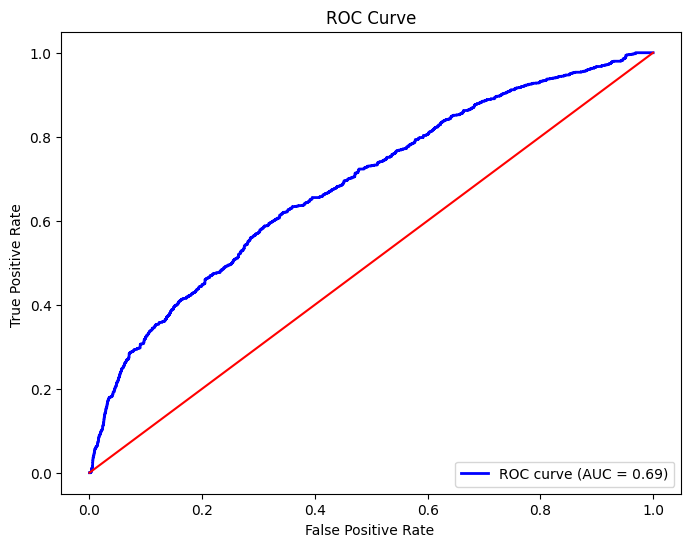

In [47]:

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='-') 
plt.xlabel('False Positive Rate ')
plt.ylabel('True Positive Rate ')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()

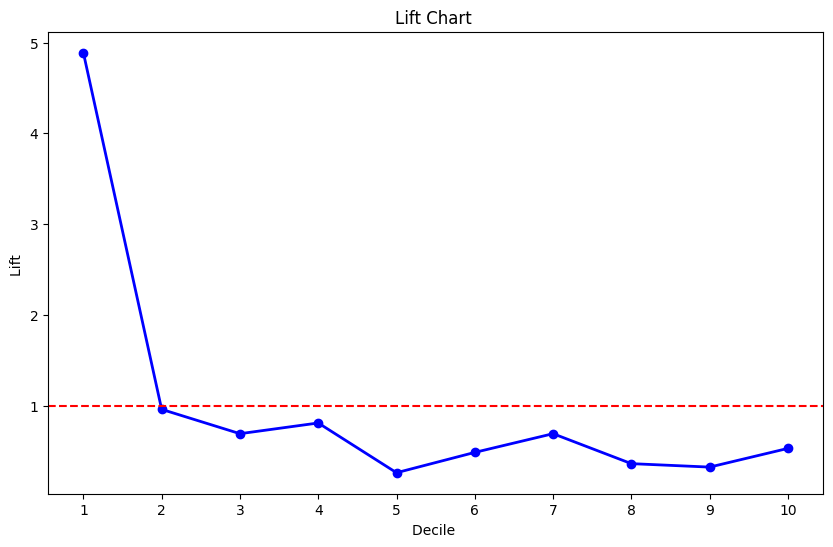

In [48]:

deciles = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
lifts = [4.888, 0.959, 0.691, 0.809, 0.261, 0.485, 0.691, 0.361, 0.323, 0.529]

plt.figure(figsize=(10, 6))

plt.plot(deciles, lifts, marker='o', linestyle='-', color='blue', linewidth=2, label='Model Lift')


plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Baseline (1.0)')


plt.title('Lift Chart ')
plt.xlabel('Decile ' )
plt.ylabel('Lift ')
plt.xticks(deciles)  


plt.show()

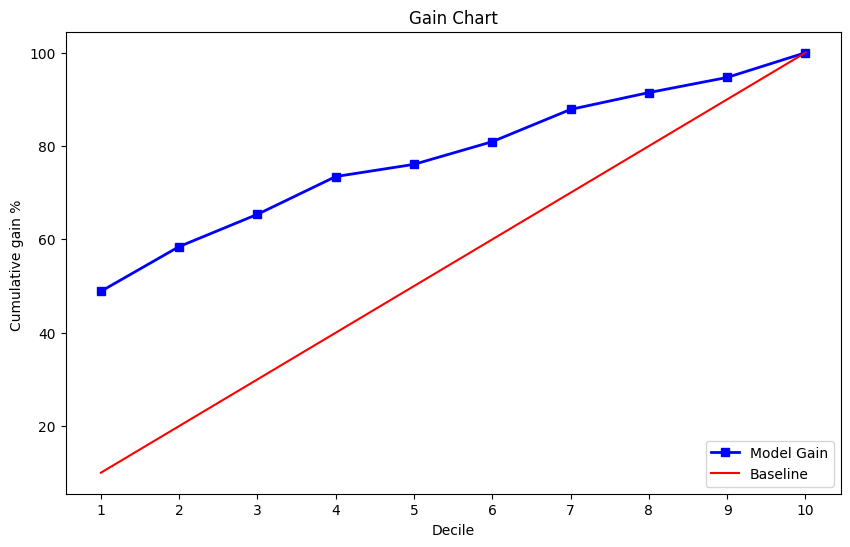

In [72]:

cumulative_gain = [48.87, 58.46, 65.37,73.47,76.08,80.94,87.85,91.46,94.70,100.00]
baseline = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

plt.figure(figsize=(10, 6))

plt.plot(deciles, cumulative_gain, marker='s', linestyle='-', color='blue', linewidth=2, label='Model Gain')

plt.plot(deciles, baseline, linestyle='-', color='red', label='Baseline')

plt.title('Gain Chart')
plt.xlabel('Decile')
plt.ylabel('Cumulative gain % ')
plt.xticks(deciles, ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])

plt.legend(loc='lower right')

plt.show()

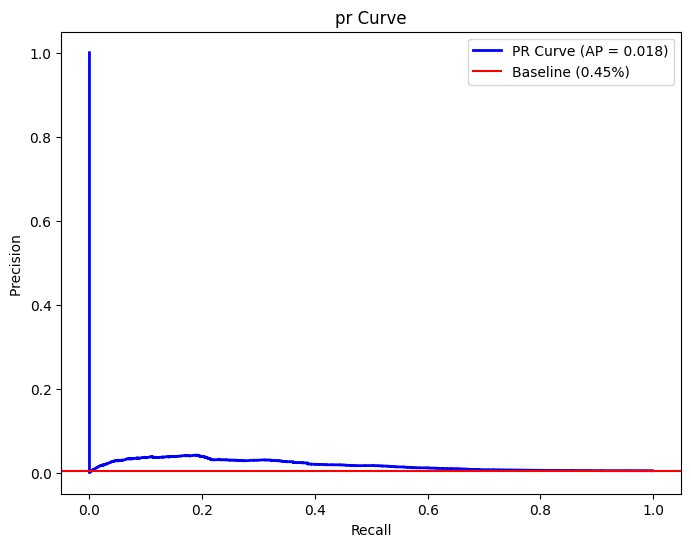

In [112]:


precision, recall, thresholds = precision_recall_curve(label_test, probs)
avg_precision = average_precision_score(label_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AP = {avg_precision:.3f})')
plt.axhline(y=0.004550090662, color='red', linestyle='-', label='Baseline (0.45%)') 

plt.xlabel('Recall')
plt.ylabel('Precision ')
plt.title('pr Curve')
plt.legend(loc="upper right")

plt.show()